### Instalando bibliotecas

In [ ]:
import sys
!{sys.executable} -m pip install langgraph langchain langchain-google-genai langchain-community langchain-tavily langchain-chroma langchain-huggingface google-genai chromadb pandas beautifulsoup4 pydantic transformers==4.40.0 sentence-transformers==2.7.0

In [ ]:
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [ ]:
import sys

# 1. Remove tudo que pode estar conflitando
!{sys.executable} -m pip uninstall -y torch torchvision torchaudio

# 2. Instala a versão específica para CUDA 11.8 (que suporta sua MX350)
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# 3. Garante que as bibliotecas de IA não sobrescrevam o torch
!{sys.executable} -m pip install transformers==4.40.0 sentence-transformers==2.7.0 langchain-huggingface langchain-chroma

In [1]:
import os, json, time, re
from getpass import getpass
from typing import TypedDict, Annotated, List, Literal, Optional, Dict, Any
from operator import add
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage
from langchain_core.documents import Document
from langchain_classic.storage import LocalFileStore
from langchain_classic.storage import create_kv_docstore
from langchain_core.output_parsers import StrOutputParser
from tenacity import retry, wait_fixed, stop_after_attempt
from langchain_chroma import Chroma
from IPython.display import display, Image
from sentence_transformers import CrossEncoder
from pydantic import BaseModel, Field
from datasets import Dataset
from ragas import evaluate

from langchain_huggingface import HuggingFaceEmbeddings
from IPython.display import clear_output
import torch

/home/andre/TCC/.venv/lib/python3.10/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### Configurando chaves de API

In [3]:
if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass("Gemini API Key: ")
if "HF_TOKEN" not in os.environ:
    os.environ["HF_TOKEN"] = getpass("Hugging Face Token: ")

### Setup

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo detectado: {device}")

# O BERTimbau Base é o ideal para os 2GB de VRAM da sua MX350
model_name = "tcepi/sts_bertimbau"

# Configurações para otimizar o uso da memória de vídeo (VRAM)
model_kwargs = { 'device': device }
encode_kwargs = {'normalize_embeddings': True, 'batch_size': 32} # Batch menor para evitar estouro de memória na MX350

embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs,
    multi_process=False
)

cross_encoder = CrossEncoder(
    'unicamp-dl/mMiniLM-L6-v2-en-pt-msmarco-v2', 
    device=device,
    max_length=512
)

Dispositivo detectado: cuda


No sentence-transformers model found with name neuralmind/bert-base-portuguese-cased. Creating a new one with MEAN pooling.
/home/andre/TCC/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/andre/TCC/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
def log_retry_attempt(retry_state):
    # retry_state.outcome.exception() captura o erro exato que aconteceu na chamada
    erro = retry_state.outcome.exception()
    tentativa = retry_state.attempt_number
    print(f"⚠️ [Tentativa {tentativa} Falhou] Aguardando próximo passo... Erro real: {erro}", flush=True)

@retry(
    wait=wait_fixed(60), 
    stop=stop_after_attempt(5),
    reraise=True,
    before_sleep=log_retry_attempt
)
def invoke_safe(modelo, prompt):
    response = modelo.invoke(prompt)
    print(("-"*50)+'\n', response, flush=True)
    return response

# Perfil 1: Rigor Analítico Absoluto (Filtros, Queries e Sínteses)
llm_analitico = init_chat_model(model="google_genai:gemini-3.1-flash-lite", temperature=0.0)

# Perfil 2: Fluidez Comunicativa (Rascunho de Resposta Empática)
llm_comunicativo = init_chat_model(model="google_genai:gemini-3.1-flash-lite", temperature=0.4)


In [5]:
base_path = os.path.dirname(os.path.abspath("__file__")) # Ou o caminho da pasta raiz do TCC
docstore_path = os.path.join(base_path, "docstore")

fs = LocalFileStore(docstore_path)
doc_store = create_kv_docstore(fs)

### Definindo o estado do grafo

In [6]:
class AgentState(TypedDict):
    # O Annotated com 'add' permite que novas mensagens sejam anexadas ao histórico
    messages: Annotated[List[BaseMessage], add] 
    demand_obj: Dict[str, Any]
    queries: List[str]
    rag_docs: Dict[str, str] 
    draft_response: str
    verdict: str
    is_verified: bool
    summary: str
    references: List[str]
    link_map: Dict[str, str] # auxiliar

### Agente 1: Agente de triagem

In [7]:
TRIAGE_PROMPT = """
    Você é um analista linguístico neutro, especializado em comunicação pública e psicologia. 
    Você está terminantemente PROIBIDO de julgar a veracidade de alguma informação. Você não possui conhecimento médico para isso.
    Sua tarefa é analisar objetivamente a demanda e a intenção do autor leigo do texto em <entrada>, 
    mapeando a estrutura da argumentação e os riscos psicoemocionais associados.
    Siga estritamente as diretrizes abaixo para preencher o contrato de dados gerado pela API.
    
    # DIRETRIZES DA ANÁLISE DE RACIOCÍNIO:    
    ## 1. Identifique a intenção real:
        - O que o autor quer saber? Qual a motivação do autor? Resuma a demanda central, e identifique se envolve medo, reprodução de boato ou dúvida genuína.
    
    ## 2. Identifique a linha de raciocínio: 
        - Alegação: extraia a alegação ou conclusão central que o autor assume como verdadeira ou possível, sem julgá-la.
        - Evidência: SE HOUVER, extraia a evidência, relato ou dado principal que o autor usa para apoiar a alegação.
        - Formule 2 Perguntas Críticas breves (de 1 ou 2 frases cada):
            1. Pergunta Crítica 1: Questione a procedência da alegação e se há uma evidência com relação de causalidade.
            2. Pergunta Crítica 2 (SE HOUVER EVIDÊNCIA): Questione se a evidência é um evento recorrente, com respaldo científico ou apoiado por fontes institucionais legítimas.

    ## 3. Traduza a intenção real em uma demanda clínica:
        - Considerando a "Alegação" e a "Evidência" do passo anterior, formule uma pergunta direta, sem vieses e clinicamente relevante. Esta pergunta deve guiar o sistema de busca (RAG) para encontrar a evidência científica exata que sana a dúvida do autor.
    
    ## 4. Extraia palavras-chave:
        - Liste os termos e conceitos fundamentais que definem a demanda central do usuário (ex: "COVID-19", "vacina", "autismo", "DNA", "tratamento alternativo").
        
    Este é um exemplo de análise de raciocínio seguindo as diretrizes acima:
    <exemplo_raciocinio>
    Alegação: As vacinas contra a gripe não funcionam mais.
    Evidência: Toda a família do autor tomou a vacina no ano passado e, ainda assim, todos pegaram resfriados e gripes fortes durante o inverno.
    Pergunta Crítica 1: Qual é a eficácia da vacina de Influenza? É capaz de prevenir todos os casos de gripe ou resfriado?
    Pergunta Crítica 2: Todos os casos de resfriado ou gripe fortes são causados por Influenza ou há outros vírus respiratórios não cobertos pelo imunizante sazonal?
    Demanda: Qual é a eficácia da vacina da Influenza na redução de hospitalizações por gripe sazonal e qual a diferença entre os sintomas da gripe e de outros resfriados comuns?
    Palavras-Chave: [vacina, influenza, gripe, resfriado]
    </exemplo_raciocinio>
    
    # DIRETRIZES DA ANÁLISE PSICOEMOCIONAL:
    1. Detecte na linguagem da <entrada> estes indicadores de alerta (avaliação binária; True/False): 
        - [ceticismo] Desconfiança de órgãos oficiais ou cinismo médico.
        - [risco_saude] Menção a comportamentos perigosos. Exemplos: interrupção de tratamentos, automedicação ou negligência de sintomas.
        - [urgencia_emocional] Presença de ansiedade ou desespero que possa comprometer a tomada de decisão do autor.
    
    2. Classifique a linguagem da <entrada> com o tom predominante (selecionar um):
        - "ansiedade": Manifestação de medo de sequelas ou busca por curas imediatas.
        - "busca_validacao": Uso de raciocínio motivado buscando confirmar uma crença ou boato prévio.
        - "desatencao": Reprodução simples ou informal de um boato por falta de reflexão atenta.
        - "neutro": Ausência de indicadores emocionais ou de viés cognitivo claro.

    # REGRA DE ESCOPO CRÍTICA:
    Se o texto da entrada estiver fora do escopo de saúde pública, preencha apenas o campo "analise_geral" com uma descrição do tema fora do escopo, e deixe todos os outros campos vazios (null ou strings vazias).
    
    # ENTRADA
    <entrada>
    {input}
    </entrada>
    
    
"""

In [8]:
class RascunhoAnaliseRaciocinio(BaseModel):
    intencao_real: str = Field(description="Disserte sobre a necessidade do autor e sua motivação.")
    alegacao: str = Field(description="Disserte sobre a alegação central do autor.")
    evidencia: Optional[str] = Field(None, description="Disserte sobre a evidência principal do autor (ou null se não houver).")
    construcao_perguntas_criticas: str = Field(description="Desenvolva aqui o raciocínio para criar as perguntas críticas.")

class RascunhoAnalisePsicoemocional(BaseModel):
    indicadores_de_alerta: str = Field(description="Sua análise qualitativasobre a presença ou ausência dos indicadores de alerta, e os sinais textuais que justificam cada um.")
    tom_detectado: str = Field(description="Sua análise qualitativa sobre a categoria de tom predominante, e a justificativa para selecionar a categoria específica.")

class RascunhoTriagem(BaseModel):
    # Estas duas sub-classes no topo forçam o modelo a gastar computação pensando antes de decidir
    analise_raciocinio: RascunhoAnaliseRaciocinio = Field(description="Primeira etapa: Análise lógica da estrutura do argumento.")
    analise_psicoemocional: RascunhoAnalisePsicoemocional = Field(description="Segunda etapa: Análise psicológica e mapeamento de riscos.")

class Indicadores(BaseModel):
    ceticismo: bool = Field(description="True se houver desconfiança de órgãos oficiais ou cinismo médico.")
    risco_saude: bool = Field(description="True se houver menção a comportamentos perigosos (interrupção de tratamentos, automedicação, negligência).")
    urgencia_emocional: bool = Field(description="True se houver presença de ansiedade ou desespero capaz de comprometer o discernimento.")
    tom_predominante: str = Field(description="Selecione estritamente uma opção: ansiedade | busca_validacao | desatencao | neutro")
    justificativa: str = Field(description="Resumo das justificativas dos indicadores e do tom predominante identificados.")

class Triagem(BaseModel):
    rascunho_triagem: RascunhoTriagem = Field(
        description="OBRIGATÓRIO: Execute esta análise estruturada por etapas ANTES de preencher qualquer campo subsequente."
    )
    
    analise_geral: str = Field(description="Seu raciocínio sobre o que o usuário está perguntando ou alegando, com qual intenção, e quais elementos de autoridade ou evidência ele cita (exemplo: 'O usuário busca saber se há relação entre X e Y, apoiando-se na fala de uma figura pública'). Não dê vereditos sobre a veracidade.")
    alegacao: str = Field(description="A conclusão ou alegação central do autor, sem ruídos.")
    evidencia: Optional[str] = Field(None, description="A evidência principal do autor (ou null se não houver).")
    pergunta_critica_1: str = Field(description="A primeira pergunta crítica, que questiona a alegação.")
    pergunta_critica_2: Optional[str] = Field(None, description="A segunda pergunta crítica, que questiona o respaldo científico da evidência (ou null se não houver).")
    demanda: str = Field(description="A pergunta direta (demanda clínica), sem vieses e neutra, que o autor precisa ver respondida.")
    palavras_chave: List[str] = Field(description="Lista contendo os termos ou conceitos fundamentais em saúde extraídos do texto do autor.")
    indicadores: Indicadores = Field(description="Mapeamento dos indicadores psicoemocionais.")

In [9]:
def get_triage(state: AgentState):
    """Analisa a intenção e os riscos da mensagem original do usuário."""        
    user_message = state["messages"][0].content 
    
    structured_llm = llm_analitico.with_structured_output(Triagem)
    prompt_formatado = TRIAGE_PROMPT.format(input=user_message)
    response = invoke_safe(structured_llm, prompt_formatado)
    time.sleep(20)
       
    demanda_dict = response.model_dump(exclude={'rascunho_triagem'})
    rascunho_json = json.dumps(response.model_dump()['rascunho_triagem'], ensure_ascii=False)
    
    return {
        "messages": [AIMessage(content=rascunho_json)],
        "demand_obj": demanda_dict,
    }

### Agente 2: Transformação de query

In [10]:
QUERIES_PROMPT = """
    Você é um profissional em Recuperação de Informação (IR) e combate à desinformação. 
    Sua entrada é <demanda_estruturada>, que contém uma alegação leiga em saúde pública, e possivelmente uma evidência informal.
    Sua primeira entrada é <demanda_estruturada>, um objeto JSON resultante da triagem clínica e psicológica do paciente. Você deve interpretar este objeto com base nas seguintes chaves nativas:
        - alegacao: A alegação ou boato central isolado do texto do autor leigo.
        - evidencia: O relato informal ou justificativa que o autor trouxe (pode ser null).
        - demanda: A pergunta clínica neutra e sem vieses.
        - palavras_chave: Os conceitos-chave em saúde extraídos para a recuperação.
        - indicadores: O mapeamento de risco emocional (ceticismo, risco_saude, urgencia_emocional, tom_predominante).
    Sua tarefa é transformar a demanda e as perguntas críticas em 4 queries de busca distintas para um Vector Database de notícias e checagens de fatos.
    Siga estritamente as diretrizes abaixo.

    # DIRETRIZES DE GERAÇÃO DAS QUERIES:
    Para garantir a cobertura total no Vector Database, você deve gerar quatro perspectivas:

    1. query_direta: Focada na alegação principal.
    2. query_hyde: Resposta hipotética em tom editorial.
    3. query_step_back: Focada no princípio biológico/médico abstrato que rege o tema.
    4. query_checagem: Focada na linguagem típica de checagens de fatos (debunking).

    # DIRETRIZES DE FORMATAÇÃO:
    - Cada query deve ter no máximo 15 palavras.
    - Remova palavras de parada (stop-words) desnecessárias, mas mantenha o sentido semântico (o Vector Database se beneficia de frases curtas e naturais).
    - Não use operadores booleanos (AND, OR), apenas linguagem natural técnica.
    
    # ENTRADA
    <demanda_estruturada>
    {input}
    </demanda_estruturada>
    
"""

In [11]:
class Queries(BaseModel):
    query_direta: str = Field(
        description="Usando a demanda e as palavras-chave extraídas, escreva uma query completa e direta pela alegação principal para encontrar notícias relacionadas ao evento. Exemplo: 'Vacina de COVID-19 causa alteração em DNA e infarto?'"
    )
    query_hyde: str = Field(
        description="Escreva uma resposta técnica hipotética que imite o estilo editorial de uma checagem de fatos, que responderia cientificamente ao boato. Exemplo: 'Não há evidências suficientes para o uso da ivermectina contra a covid-19'. NÃO adicione nomes de instituições (como OMS, Ministério da Saúde, Anvisa) a menos que estejam explícitas nas palavras-chave da demanda."
    )
    query_step_back: str = Field(
        description="Escreva uma query focada no princípio biológico, farmacológico ou epidemiológico que rege o tema. Exemplo: Se a alegação é que 'tomar chá de boldo concentrado com limão cura a Dengue', a query pode ser 'manejo clínico da dengue e eficácia de fitoterápicos no tratamento antiviral'"
    )
    query_checagem: str = Field(
        description="Escreva uma query adaptada para o estilo de redação de agências de fact-checking, contendo termos como 'é boato'. Exemplo: 'É BOATO que uso prolongado de máscara contra o coronavírus causa intoxicação'"
    )

class ExpansaoQueries(BaseModel):
    queries: Queries = Field(
        description="Objeto contendo as 4 queries expandidas de forma estruturada."
    )

In [12]:
def get_queries(state: AgentState):
    """Transforma a análise de intenção em queries para o VectorDB."""
    
    structured_llm = llm_analitico.with_structured_output(ExpansaoQueries)
    prompt_formatado = QUERIES_PROMPT.format(input=json.dumps(state["demand_obj"], ensure_ascii=False))
    response = invoke_safe(structured_llm, prompt_formatado)
    time.sleep(20)
       
    queries = list(response.queries.model_dump().values())
        
    return {"queries": queries}

### Agente 3: Recuperação de documentos

In [13]:
def get_domain(url: str) -> str:
    """Extrai o domínio principal de uma URL usando regex com base na regra fornecida."""
    if url == "SEM LINK":
        return url
        
    # Regex adaptada à sua lógica:
    # 1. Procura por 'http' seguido por '://' opcional ou diretamente
    # 2. Ignora o 'www.' se estiver presente
    # 3. Captura tudo até a próxima barra '/' (ou fim da string)
    match = re.search(r"https?://(?:www\.)?([^/]+)", url)
    
    if match:
        return match.group(1)
        
    return "SEM LINK"

async def retrieve_documents(state: AgentState):
    """Busca documentos reais no ChromaDB usando as 3 queries expandidas."""
    

    vector_db = Chroma(
        collection_name="base_noticias",
        persist_directory="./chroma_db", 
        embedding_function=embeddings
    )
    
    demanda = state["demand_obj"]["demanda"]
    queries = state["queries"]

    todos_documentos_candidatos = []
    for q in queries:
        docs_busca = vector_db.similarity_search(q, k=30)
        todos_documentos_candidatos.extend(docs_busca)
        
    ids_vistos = set()
    documentos_unicos = []
    for doc in todos_documentos_candidatos:
        doc_id = str(doc.metadata.get('id')) # ou o nome da chave que você definiu na ingestão
        if doc_id not in ids_vistos:
            print(("-"*50)+'\n', doc.page_content, flush=True)
            ids_vistos.add(doc_id)
            documentos_unicos.append(doc)

    if not documentos_unicos:
        print("⚠️ Nenhum documento retornado pelo banco de vetores.")
        return {"rag_docs": {}}
    
    parent_ids = [str(doc.metadata.get('id')) for doc in documentos_unicos]
    
    # store.mget retorna uma lista de objetos Document (ou None se a chave não existir)
    documentos_pais = doc_store.mget(parent_ids)
    
    pares_relevancia = []
    docs_validos = [] 
    
    for doc, doc_pai in zip(documentos_unicos, documentos_pais):
        if doc_pai is not None:
            pares_relevancia.append([demanda, doc_pai.page_content])
            docs_validos.append(doc) # Guarda o doc original apenas se o pai existir
            
    if not pares_relevancia:
        print("⚠️ Nenhum documento pai encontrado no docstore.")
        return {"rag_docs": {}}
    
    # Executa a predição de similaridade profunda na GPU
    scores_semanticos = cross_encoder.predict(pares_relevancia, batch_size=8)
    
    ano_atual = 2026
    ano_piso = 2016
    
    candidatos_com_score = []
    for doc, score in zip(docs_validos, scores_semanticos):
        if score >= 0.4:
            candidatos_com_score.append((doc, score))
        ano_doc = int(re.search(r'\d{4}', doc.metadata.get('data', str(ano_piso))).group())
        ano_doc = max(ano_piso, min(ano_atual, ano_doc))
        score_temporal = (ano_doc - ano_piso) / (ano_atual - ano_piso)
        score_final = (0.7 * score) + (0.3 * score_temporal)
        if score_final >= 0.4:
            candidatos_com_score.append((doc, score_final))
    candidatos_com_score.sort(key=lambda x: x[1], reverse=True)
    candidatos_com_score = candidatos_com_score[:12]
    
    link_map = {str(doc.metadata.get('id')): doc.metadata.get('link') for doc, score in candidatos_com_score}
    
    
    documentos_filtrados = {}
    for doc, score in candidatos_com_score:
        id = str(doc.metadata.get('id', 'N/A')).strip()
        data_meta = str(doc.metadata.get('data', ano_piso))
        match_ano = re.search(r'\d{4}', data_meta)
        ano_extraido = match_ano.group() if match_ano else str(ano_piso)
        doc_formatado = (
            f"ID: {id} | "
            f"ANO: {ano_extraido} | "
            f"FONTE_VERIFICADA: {doc.metadata.get('verificado', 'False')} | "
            f"FONTE: {get_domain(doc.metadata.get('link', 'SEM LINK'))} | "
            f"TITULO: {doc.metadata.get('titulo', 'SEM TÍTULO')} | "
            f"SUBTITULO: {doc.metadata.get('subtitulo', 'SEM SUBTÍTULO')} | "
            f"TRECHO_EXTRAIDO: {doc.page_content}."
        )
        if (id != 'N/A'):
            documentos_filtrados[id] = doc_formatado
            
    print(f"🔍 RAG + Cross-Encoder: {len(documentos_unicos)} docs avaliados -> {len(documentos_filtrados)} passaram pelo corte (score >= 0.4).")
    
    if not documentos_filtrados:
        print("⚠️ Nenhum documento filtrado pelo banco de vetores.")
        return {"rag_docs": {}}
    
    # Atualiza o estado com os documentos finais e define se o RAG foi útil
    return {
        "rag_docs": documentos_filtrados,
        "link_map": link_map
    }

### Agente 4: Avaliação de documentos

In [ ]:
    RANKER_PROMPT = """
        Você é um profissional em Recuperação de Informação (IR) e combate à desinformação. 
        Sua primeira entrada é <demanda_estruturada>, um objeto JSON resultante da triagem clínica e psicológica do paciente. Você deve interpretar este objeto com base nas seguintes chaves nativas:
            - alegacao: A alegação ou boato central isolado do texto do autor leigo.
            - evidencia: O relato informal ou justificativa que o autor trouxe (pode ser null).
            - demanda: A pergunta clínica neutra e sem vieses.
            - palavras_chave: Os conceitos-chave em saúde extraídos para a recuperação.
            - indicadores: O mapeamento de risco emocional (ceticismo, risco_saude, urgencia_emocional, tom_predominante).
        Sua segunda entrada é <docs>, uma lista de documentos recuperadas via RAG para responder à demanda. Você NÃO tem acesso ao documento completo, apenas ao conjunto: título, subtítulo, trecho extraído. 
        Sua tarefa é rotular binariamente cada documento, como relevante / irrelevante, julgando pelos dados fornecidos se o documento está dentro do tema / contexto, e é provável de atender a demanda.
        Por fim, selecione os 4 documentos mais relevantes para a demanda.
        Siga estritamente as diretrizes abaixo.

        # DIRETRIZES DE AUDITORIA:
        Se houver mais de 4 documentos rotulados "relevante", use estes critérios de desempate na seleção:
        1. PRIORIDADE PARA FONTE VERIFICADA
            - Se o documento tiver o atributo "FONTE_VERIFICADA" == True, deve ter prioridade.

        2. PRIORIDADE PARA DATA RECENTE
            - Considere 2026 como o ano atual. Em saúde pública, a informação evolui rapidamente. Penalize documentos com dados ou diretrizes antigas (ex: 2021) se houver documentos mais recentes (ex: 2025/2026) que os atualizem.
        
        # Entrada
        <demanda_estruturada>
        {demanda}
        </demanda_estruturada>
        
        <docs>
        {docs}
        </docs>
        
    """

In [ ]:
RANKER_2_PROMPT = """
    Você é um profissional em Recuperação de Informação (IR) e combate à desinformação. 
    Sua primeira entrada é <demanda_estruturada>, um objeto JSON resultante da triagem clínica e psicológica do paciente. Você deve interpretar este objeto com base nas seguintes chaves nativas:
        - alegacao: A alegação ou boato central isolado do texto do autor leigo.
        - evidencia: O relato informal ou justificativa que o autor trouxe (pode ser null).
        - demanda: A pergunta clínica neutra e sem vieses.
        - palavras_chave: Os conceitos-chave em saúde extraídos para a recuperação.
        - indicadores: O mapeamento de risco emocional (ceticismo, risco_saude, urgencia_emocional, tom_predominante).
    Sua segunda entrada é <docs>, uma lista de documentos possíveis para responder à demanda. Você precisa validar a relevância destes, um por um.
    Sua tarefa é rotular binariamente cada documento, como relevante / irrelevante. Por fim, selecionar os relevantes.
    Siga estritamente as diretrizes abaixo.

    # DIRETRIZES DE AUDITORIA:

    1. PRIORIDADE PARA FONTE VERIFICADA
        - Se o documento tiver o atributo "FONTE_VERIFICADA" == True, deve ter prioridade.

    2. PRIORIDADE PARA DATA RECENTE
        - Considere 2026 como o ano atual. Em saúde pública, a informação evolui rapidamente. Penalize documentos com dados ou diretrizes antigas (ex: 2021) se houver documentos mais recentes (ex: 2025/2026) que os atualizem.

    3. REDUNDÂNCIA MÍNIMA
        - Minimize a redundância (repetição de informação) entre documentos. Se dois documentos tratam do mesmo assunto, sem adicionarem entre si informações novas e relevantes para a demanda, selecione apenas um.   
        - Exemplo: se a lista contiver 4 documentos, mas apenas 2 forem categoricamente necessários para refutar a desinformação, rotule apenas estes como relevantes.
        
    # REGRA DE ESCOPO: Um documento deve ser considerado RELEVANTE se ele fornecer os fundamentos científicos, regulatórios ou jornalísticos necessários para desconstruir alegações potencialmente enganosas do paciente ou estimular questionamento das evidências anedóticas apresentadas, mesmo que não cite explicitamente as evidências do paciente.
    
    # Entrada
    <demanda_estruturada>
    {demanda}
    </demanda_estruturada>
    
    <docs>
    {docs}
    </docs>
    
"""

In [16]:
class DocumentoRelevante(BaseModel):
    id: str = Field(description="ID exato e idêntico do documento avaliado e selecionado.")
    justificativa: str = Field(description="Uma frase explicando o motivo da seleção deste documento, com foco estrito na relevância temática e na autoridade da fonte.")

class RascunhoRanker(BaseModel):
    raciocinio: str = Field(
        description="Resuma a evidência que deve ser encontrada para atender a demanda clínica, explicando brevemente a lógica de priorização a usar para definir quais documentos serão selecionados."
    )
    auditoria_individual: str = Field(
        description="OBRIGATÓRIO: Para cada documento que contém tema ou informação relevante para a demanda, descreva em uma nova linha um item, prefixado por 'Doc [ID]: ', avaliando detalhadamente onde atende a demanda, se a fonte é robusta e se é cronologicamente recente considerando 2026 como o ano atual."
    )

class Ranking(BaseModel):
    rascunho_auditoria: RascunhoRanker = Field(
        description="Etapa analítica obrigatória de auditoria e julgamento lógico dos dados do RAG."
    )
    documentos_relevantes: List[DocumentoRelevante] = Field(
        default=[],
        description="Lista contendo no máximo os 4 documentos rotulados como relevantes e que melhor atendem à demanda clínica."
    )

In [17]:
def get_ranking(state: AgentState):
    """Avalia a utilidade dos documentos recuperados da base."""
    
    demand_obj = state["demand_obj"]
    documentos_rag = state["rag_docs"]
    
    print(f"🧠 [Ranker - Estágio 1] Avaliando {len(documentos_rag)} documentos candidatos...")
    
    structured_llm = llm_analitico.with_structured_output(Ranking)
    prompt_formatado = RANKER_PROMPT.format(demanda=json.dumps(demand_obj, ensure_ascii=False), docs="\n\n".join(documentos_rag.values()))
    response_1 = invoke_safe(structured_llm, prompt_formatado)
    time.sleep(20)
           
    docs_ids = [doc.id for doc in response_1.documentos_relevantes]
        
    if not docs_ids:
        print("⚠️ [Ranker] Todos os documentos foram rejeitados no Estágio 1.")
        return {"rag_docs": {}, "messages": [AIMessage(content=json.dumps(response_1.model_dump()['rascunho_auditoria'], ensure_ascii=False))]}
    
    print(f"🧠 [Ranker - Estágio 2] Aplicando filtro de redundância crítica sobre {len(docs_ids)} documentos...")
    
    documentos_pais = doc_store.mget(docs_ids)
        
    docs_relevantes = {}
    for id, doc_pai in zip(docs_ids, documentos_pais):
        doc = documentos_rag[id]
        if not doc or doc_pai is None:
            continue
        
        link = get_domain(state['link_map'].get(id, "SEM LINK"))
        # Encontra a posição onde começa "TITULO:"
        posicao = doc.find("TITULO:")
        if posicao != -1:
            nova_string = doc[:posicao] + doc_pai.page_content
        else:
            with open("debug_ranking.txt", "a", encoding="utf-8") as f:
                f.write(f"⚠️ [RANKER DEBUG] Formato inesperado para o documento ID {id}. String original: {doc}\n")
            match_ano = re.search(r'\d{4}', doc)
            ano_extraido = match_ano.group() if match_ano else '2016'
            whitelist = [".aosfatos.org",".agencialupa.org",".gov.br",".estadao.com.br",".uol.com.br",".afp.com"]
            nova_string = f"ID: {id} | ANO: {ano_extraido} | FONTE_VERIFICADA: {str(any(domain in link for domain in whitelist))} | FONTE: {link} | {doc_pai.page_content}" # Fallback seguro
        docs_relevantes[id] = nova_string

    structured_llm = llm_analitico.with_structured_output(Ranking)
    prompt_formatado = RANKER_2_PROMPT.format(demanda=json.dumps(demand_obj, ensure_ascii=False), docs="\n\n".join(docs_relevantes.values()))
    response_2 = invoke_safe(structured_llm, prompt_formatado)
    time.sleep(20)
    
    is_verified = False
    referencias = []
    
    docs_ids = [doc.id for doc in response_2.documentos_relevantes]
    if docs_ids: 
        referencias = [link for link in [state['link_map'].get(id, "") for id in docs_ids] if link]
        justificativas = [doc.justificativa for doc in response_2.documentos_relevantes]
        
        docs_relevantes = {id: v for id, v in docs_relevantes.items() if id in docs_ids}
            
        for id, justificativa in zip(docs_ids, justificativas):
            if not docs_relevantes.get(id):
                raise ValueError(f"Documento com ID {id} não encontrado entre os documentos relevantes.")
            docs_relevantes[id] = f"JUSTIFICATIVA: {justificativa} | {docs_relevantes[id]}"
            
        is_verified = any("FONTE_VERIFICADA: True" in doc for doc in docs_relevantes.values())
    else:
        docs_relevantes = {}
    print(f"🎯 [Ranker] Processo concluído. Veredito final de utilidade dos documentos: {len(docs_relevantes)}")
    
    return {
        "rag_docs": docs_relevantes, 
        "is_verified": is_verified,
        "references": referencias,
        "messages": [AIMessage(content=json.dumps(response_1.model_dump()['rascunho_auditoria'], ensure_ascii=False)), AIMessage(content=json.dumps(response_2.model_dump()['rascunho_auditoria'], ensure_ascii=False))]
    }

### Agente 5: Síntese

In [18]:
SUMMARIZE_PROMPT = """
Você é um profissional de comunicação em saúde pública. 
Sua primeira entrada é <demanda_estruturada>, um objeto JSON resultante da triagem clínica e psicológica do paciente. Você deve interpretar este objeto com base nas seguintes chaves nativas:
    - alegacao: A alegação ou boato central isolado do texto do autor leigo.
    - evidencia: O relato informal ou justificativa que o autor trouxe (pode ser null).
    - demanda: A pergunta clínica neutra e sem vieses.
    - palavras_chave: Os conceitos-chave em saúde extraídos para a recuperação.
    - indicadores: O mapeamento de risco emocional (ceticismo, risco_saude, urgencia_emocional, tom_predominante).
Sua segunda entrada é o texto integral de um documento científico ou jornalístico, iniciado por uma breve justificativa da utilidade do documento para responder à demanda.
Sua tarefa é criar um resumo que preserve as informações mais importantes do documento. 
Extraia os fatos, estatísticas, dados numéricos ou trechos exatos contidos EXCLUSIVAMENTE neste documento que sirvam para responder ou refutar o boato do usuário, guiando-se pela justificativa do agente avaliador.

# DIRETRIZES RESTRITIVAS
- Gere como saída apenas o resumo do documento, texto puro, sem comentários adicionais. 
- Não utilize qualquer conhecimento externo.
- Retorne a resposta em formato de tópicos curtos e objetivos (bullet points).

Por favor, siga estas diretrizes para criar seu resumo:

1. Identifique e preserve o tópico principal ou propósito da página web.
2. Mantenha fatos-chave, estatísticas e pontos de dados que são centrais para a mensagem do conteúdo.
3. Mantenha citações importantes de fontes confiáveis ou especialistas.
4. Mantenha a ordem cronológica dos eventos se o conteúdo for sensível ao tempo ou histórico.
5. Preserve quaisquer listas ou instruções passo a passo, se presentes.
6. Inclua datas, nomes e locais relevantes que são cruciais para entender o conteúdo.
7. Resuma explicações longas mantendo a mensagem central intacta.

Seu resumo deve ser claro e significativamente mais curto que o conteúdo original, mas abrangente o suficiente para se sustentar como uma fonte de informação. Procure cerca de um quarto do comprimento original, a menos que o conteúdo já seja conciso.

# ENTRADA
<demanda_estruturada>
{demanda}
</demanda_estruturada>

<documento>
{documento}
</documento>

"""

In [19]:
SUMMARIZE_ALL_PROMPT = """
    Você é um profissional de comunicação em saúde pública. 
    Sua primeira entrada é <demanda_estruturada>, um objeto JSON resultante da triagem clínica e psicológica do paciente. Você deve interpretar este objeto com base nas seguintes chaves nativas:
        - alegacao: A alegação ou boato central isolado do texto do autor leigo.
        - evidencia: O relato informal ou justificativa que o autor trouxe (pode ser null).
        - demanda: A pergunta clínica neutra e sem vieses.
        - palavras_chave: Os conceitos-chave em saúde extraídos para a recuperação.
        - indicadores: O mapeamento de risco emocional (ceticismo, risco_saude, urgencia_emocional, tom_predominante). 
    Sua segunda entrada é uma série de resumos de documentos científicos ou jornalísticos, com a fonte anexada no ínicio.
    Sua tarefa é condensar todos os resumos em um único, dissertando sobre o consenso ou ausência de consenso entre as fontes e destacar, de cada documento, as informações essenciais para responder à demanda clínica.
    
    # REGRA CRÍTICA DE REFERÊNCIA À FONTE: 
    - Ao condensar qualquer resumo da lista <resumos> para compor o resumo final, referencie (no mínimo uma vez) a "FONTE" do resumo de origem. 
    - Se vier acompanhada do rótulo "FONTE_VERIFICADA: True", destaque isso no texto. Exemplo: "O portal agencialupa.org, fonte verificada cientificamente, afirma que..."
    - Caso seja "FONTE_VERIFICADA: False", use apenas os trechos que noticiam disseminação de boato na mídia (se houver), e destaque o caráter jornalístico no texto. Exemplo: "O portal boatos.org, fonte jornalística não científica, reporta que o boato foi disseminado nas redes sociais..."
    
    # DIRETRIZES RESTRITIVAS
    1. Gere como saída apenas o resumo do documento, texto puro, sem comentários adicionais. 
    2. Não utilize qualquer conhecimento externo.
    3. Mantenha fatos-chave, estatísticas e pontos de dados que são centrais para atender a demanda.
    4. Mantenha citações importantes de fontes confiáveis ou especialistas.
    5. Mantenha a ordem cronológica dos eventos se o conteúdo for sensível ao tempo ou histórico.
    6. Preserve quaisquer listas ou instruções passo a passo, se presentes.
    
    O objetivo é criar um resumo claro e utilizável por um profissional de saúde.

    # ENTRADA
    <demanda_estruturada>
    {demanda}
    </demanda_estruturada>

    <resumos>
    {resumos}
    </resumos>

"""


In [20]:
def get_summary(state: AgentState):
    """
    Sintetiza as evidências encontradas iterando documento por documento 
    e depois cria um consenso consolidado.
    """
    # Inicializando o modelo com temperatura baixa para manter rigor na síntese
    
    demanda = state["demand_obj"]
    documentos = state["rag_docs"]
    
    todas_responses = []
    resumos_individuais = []
    
    print(f"✍️ [Síntese] Gerando resumos individuais para {len(documentos)} documentos...")
    
    # 1. Iteração sobre cada documento da lista
    for i, doc in enumerate(documentos.values(), start=1):
        prompt_individual = SUMMARIZE_PROMPT.format(
            demanda=json.dumps(demanda, ensure_ascii=False),
            documento=doc
        )
        print("-"*50+'\n', f"Gerando resumo para o documento {i}:\n{doc}\n", flush=True)
        texto_puro = llm_analitico | StrOutputParser()
        response = invoke_safe(texto_puro, prompt_individual)
        time.sleep(20)
        todas_responses.append(response) # Guarda a chamada no histórico
        
        # Adiciona o cabeçalho exigido e guarda na lista de textos
        match1 = re.search(r"(JUSTIFICATIVA:.*?\|)", doc) # Investigar presença da justificativa vinda do ranker (não crítico)
        match2 = re.search(r"(FONTE_VERIFICADA:.*?\|)", doc)
        match3 = re.search(r"(FONTE:.*?\|)", doc)
        if not (match1 and match2 and match3):
            with open("debug_ranking.txt", "a", encoding="utf-8") as f:
                f.write(f"⚠️ [RANKER DEBUG] Formato inesperado para o documento. String original: {doc[:200]}\n")
        resumos_individuais.append(f"DOCUMENTO ({i}): {match1.group(1) if match1 else ''} {match2.group(1) if match2 else ''} {match3.group(1) if match3 else ''} {response}")
        
    response_consenso = todas_responses[0]
    
    if len(resumos_individuais) > 1:
        # 2. Consolidação de todos os resumos
        resumos_combinados = "\n\n".join(resumos_individuais)
        print("-"*50+'\n', "Resumos individuais gerados:\n", resumos_combinados, flush=True)
        
        print("✍️ [Síntese] Consolidando o consenso geral...")
        
        # 3. Chamada final para a síntese de consenso
        prompt_consenso = SUMMARIZE_ALL_PROMPT.format(
            demanda=json.dumps(demanda, ensure_ascii=False),
            resumos=resumos_combinados
        )
        texto_puro = llm_analitico | StrOutputParser()
        response_consenso = invoke_safe(texto_puro, prompt_consenso)
        time.sleep(20)
        todas_responses.append(response_consenso) # Guarda a chamada final
    
    print("✅ [Síntese] Consenso gerado com sucesso.")
    
    # Retorna o resumo consolidado e todas as interações com o LLM
    return {
        "summary": response_consenso,
        "messages": todas_responses
    }

### Agente 6: Geração

In [21]:
FRIENDLY_GENERATOR_PROMPT = """
    Você é um comunicador empático de saúde pública, com compromisso estrito com a ciência.
    Sua primeira entrada é <demanda_estruturada>, um objeto JSON resultante da triagem clínica e psicológica do paciente. Você deve interpretar este objeto com base nas seguintes chaves nativas:
        - alegacao: A alegação ou boato central isolado do texto do autor leigo.
        - evidencia: O relato informal ou justificativa que o autor trouxe (pode ser null).
        - demanda: A pergunta clínica neutra e sem vieses.
        - palavras_chave: Os conceitos-chave em saúde extraídos para a recuperação.
        - indicadores: O mapeamento de risco emocional (ceticismo, risco_saude, urgencia_emocional, tom_predominante).
    Sua segunda entrada é a síntese técnica de fatos para atender a demanda, seguida dos links das referências (as fontes da informação).
    Sua tarefa é escrever uma resposta acolhedora e direta para um usuário, considerando as dúvidas ou os medos sobre o tema.
    Gere como saída apenas a resposta solicitada, em texto puro, sem comentários adicionais.
    Não adicione conhecimento externo que não possa ser diretamente verificado na síntese de fatos.
    
    CRÍTICO: Ao final da sua resposta, adicione uma quebra de linha para a seção "Referências:", que deve listar todos os links fornecidos em <referencias>.
    
    {diretrizes}
    
    # ENTRADA
    <demanda_estruturada>
    {demanda}
    </demanda_estruturada>

    <sintese>
    {sintese}
    </sintese>
    
    <referencias>
    {referencias}
    </referencias>

"""

# Bloco para o CASO 1
BLOCK_CASO_1 = """
    # ESTRUTURA EDITORIAL DA RESPOSTA
    A resposta deve ser estruturada rigorosamente nesta ordem lógica, reproduzindo a linguagem de uma consulta clínica:

    1. O FATO PRINCIPAL: Comece imediatamente com a verdade científica positiva de forma simples e direta. Nunca comece repetindo a mentira.
    2. O AVISO DE MENTIRA: Trate explicitamente da alegação, deixando claro, de forma empática, se a informação é falsa / incompleta.
    3. A EXPLICAÇÃO DA FALÁCIA: Utilizando os documentos fornecidos, explique detalhadamente a lógica por trás de erro ou fraude. Use todos os detalhes factuais disponíveis no contexto aqui, incluindo fontes e dados oficiais.
    4. O REFORÇO DO FATO: Conclua reforçando a verdade científica e fornecendo uma diretriz prática de ação.

    # DIRETRIZES DE PSICOLOGIA DE RISCO
    - Empatia: Reconheça o medo ou a dúvida do usuário com um tom acolhedor e calmo (por exemplo: "É natural ter dúvidas sobre a segurança dos nossos filhos...").
    - Transparência: Se os documentos apontarem algo que ainda está em investigação ou deixarem claro os limites do conhecimento atual, seja transparente.
    - Ação Prática: Termine sempre orientando o usuário a realizar um passo seguro (por exemplo: "Consulte a caderneta de vacinação no posto de saúde mais próximo"). 

    ## REGRA 1: DESCONSTRUÇÃO RETÓRICA 
    - O essencial é responder às "perguntas_criticas" fornecidas em <demanda_estruturada> usando os fatos em <sintese>, em detrimento de evidências anedóticas do usuário. 
    - A explicação não pode ser genérica. Deve reforçar a lógica existente entre os fatos e a demanda, e, se houver, o nexo falho entre a evidência informal e a alegação.

    ## REGRA 2: MODULAR O TOM DA RESPOSTA
    Leia o campo "tom_predominante" e "urgencia_emocional" de <demanda_estruturada> para ajustar sua resposta:
    - Se o tom for "ansiedade" ou "urgencia_emocional" for True: Valide o receio do usuário (por exemplo: "É perfeitamente compreensível ter dúvidas e querer proteger a sua família..."). Use frases curtas, tom calmo e faça analogias simples antes dos termos puramente técnicos.
    - Se o tom for "ceticismo": Adote uma postura estritamente factual e neutra. Evidencie a solidez dos estudos de <sintese>, destacando as autoridades e as fontes.
    - Se o tom for "busca_validacao": Guie gentilmente o usuário para fora do viés de confirmação, demonstrando que a conclusão dele partiu de informação incompleta.
    - Se o tom for "desatencao": Seja extremamente direto. 
"""

# Bloco para o CASO 2
BLOCK_CASO_2 = """
    # ESTRUTURA EDITORIAL DA RESPOSTA 
    A fonte da <sintese> é jornalística e não científica. Sua tarefa é apenas explicitar que a alegação ou evidência não tem embasamento científico, como aponta o debunking na fonte da síntese, e sem elaborar teorias científicas para apoiar o que foi dito.
    
    No fim da resposta gerada, adicione a seção "Referências:" e liste todos os links fornecidos na seção <referencias>.
    Atenção: as fontes citadas não devem ser as contidas no resumo, e sim os domínios dos links das referências fornecidas na seção <referencias>.
    
    1. SE A SÍNTESE DESMENTE A ALEGAÇÃO DO USUÁRIO (Debunking Jornalístico):
        Siga este modelo de resposta, substituindo as informações entre colchetes pelos dados extraídos exclusivamente de <sintese>:
        # INÍCIO DA RESPOSTA MODELO
        "[Insira uma introdução empática, dizendo que a informação está sendo circulada, e veículos jornalísticos já apontaram a falta de embasamento científico]. "
        "Segundo a(s) fonte(s) [Insira os nomes dos domínios dos links das referências], [Insira um resumo curto e puramente factual do que a fonte alega]."
        "Por isso, é importante procurar a orientação de um profissional de saúde e se atentar ao pronunciamento dos órgãos oficiais de saúde."
        # FIM DA RESPOSTA MODELO
    
    2. SE A SÍNTESE CONFIRMA UM RISCO REAL NOTICIADO (Ex: Lote de remédio recolhido):
       Explique o caso de forma factual e calma, orientando o usuário a buscar os canais oficiais do fabricante ou da Anvisa.
    
    Nota de Rigor: Mantenha a neutralidade jornalística ao preencher o resumo da fonte.
    
    # DIRETRIZES DE PSICOLOGIA DE RISCO
    - Empatia: Reconheça o medo ou a dúvida do usuário com um tom acolhedor e calmo (por exemplo: "É natural ter dúvidas sobre a segurança dos nossos filhos...").
    - Transparência: Se os documentos apontarem algo que ainda está em investigação ou deixarem claro os limites do conhecimento atual, seja transparente.
    - Ação Prática: Termine sempre orientando o usuário a realizar um passo seguro (por exemplo: "Consulte a caderneta de vacinação no posto de saúde mais próximo").
"""

In [22]:
def get_draft(state: AgentState):
    """Gera um rascunho de resposta amigável com base na síntese."""

    demanda = state["demand_obj"]
    sintese = state["summary"]
    referencias = "\n".join(state["references"])
    diretrizes = BLOCK_CASO_1 if state.get("is_verified") else BLOCK_CASO_2
    prompt = FRIENDLY_GENERATOR_PROMPT.format(sintese=sintese, demanda=json.dumps(demanda, ensure_ascii=False), diretrizes=diretrizes, referencias=referencias)
    texto_puro = llm_comunicativo | StrOutputParser()
    response = invoke_safe(texto_puro, prompt)
    time.sleep(20)
    
    return {"draft_response": response, "messages": [response]}

### Agente 7: Veredito

In [ ]:
# Prompt do Agente 8
VALIDATOR_PROMPT = """
    Você é um comunicador empático de saúde pública.
    Sua primeira entrada é <demanda_estruturada>, um objeto JSON resultante da triagem clínica e psicológica do paciente. Você deve interpretar este objeto com base nas seguintes chaves nativas:
        - alegacao: A alegação ou boato central isolado do texto do autor leigo.
        - evidencia: O relato informal ou justificativa que o autor trouxe (pode ser null).
        - demanda: A pergunta clínica neutra e sem vieses.
        - palavras_chave: Os conceitos-chave em saúde extraídos para a recuperação.
        - indicadores: O mapeamento de risco emocional (ceticismo, risco_saude, urgencia_emocional, tom_predominante).
    Sua segunda entrada é a síntese técnica de fatos para atender a demanda. 
    Sua terceira entrada é o "Rascunho de Resposta" para a demanda, cujo objetivo é ser lido por um paciente.
    Sua tarefa é revisar o "Rascunho de Resposta" gerado para o paciente, garantindo que seja 100% fiel à síntese dos fatos.

    # DÊ O VEREDITO:
    Se o rascunho não atendeu a um dos critérios (1 a 3), o veredito deve ser "INADEQUADO". Caso contrário, é "ADEQUADO".
    ## CRITÉRIOS
    1. O rascunho NÃO introduziu desinformação ou fato novo não presente na síntese.
    2. O tom é respeitoso e adequado.
    3. O rascunho responde à demanda.
    
    # O RASCUNHO DEVE SEGUIR ESTAS DIRETRIZES:
    <diretrizes>
    {diretrizes}
    </diretrizes>
      
    # ENTRADA
    <demanda_estruturada>
    {demanda}
    </demanda_estruturada>

    <sintese>
    {sintese}
    </sintese>

    <rascunho>
    {rascunho}
    </rascunho>

"""

In [24]:
class ValidatorOutput(BaseModel):
    # 🔥 O RASCUNHO VEM PRIMEIRO: Força a cadeia de pensamento crítica antes da tomada de decisão
    critica_raciocinio: str = Field(
        description="OBRIGATÓRIO: Disserte detalhadamente sobre o rascunho de resposta. Aponte de forma imparcial os pontos fortes e fracos do texto em relação às diretrizes editoriais e científicas, sugerindo melhorias."
    )
    criterio_1: bool = Field(
        description="True se o rascunho NÃO introduziu nenhuma desinformação ou fato novo / alegação biológica que não esteja explicitamente na síntese técnica."
    )
    criterio_2: bool = Field(
        description="True se o tom do rascunho for estritamente empático, respeitoso e livre de julgamentos morais."
    )
    criterio_3: bool = Field(
        description="True se o rascunho responde de forma clara e conclusiva à demanda real do paciente leigo."
    )

In [ ]:
def get_verdict(state: AgentState):
    """Valida o rascunho contra a síntese e emite a resposta final."""
        
    if not state["rag_docs"]:
        return {"verdict": "INADEQUADO", "messages": [AIMessage(content="Não fui capaz de responder à sua demanda. Procure um profissional de saúde para receber orientações.")]}    
    
    rascunho = state["draft_response"]
    demanda = state["demand_obj"]
    sintese = state["summary"]
    diretrizes = BLOCK_CASO_1 if state.get("is_verified") else BLOCK_CASO_2
    
    structured_llm = llm_analitic.with_structured_output(ValidatorOutput)
    prompt_formatado = VALIDATOR_PROMPT.format(sintese=sintese, rascunho=rascunho, demanda=json.dumps(demanda, ensure_ascii=False), diretrizes=diretrizes)
    response = invoke_safe(structured_llm, prompt_formatado)
    time.sleep(20)
    
    return {"verdict": "ADEQUADO" if response.criterio_1 and response.criterio_2 and response.criterio_3 else "INADEQUADO", "messages": [AIMessage(content=json.dumps(response.model_dump()['critica_raciocinio'], ensure_ascii=False))]}

### Definindo o grafo

In [26]:
def post_rag(state: AgentState) -> Literal["continue", "break"]:
    """
    Avalia se o RAG retornou documentos. 
    Se estiver vazio (Caso 1), pula direto para o gerador de rascunho para emitir a frase padrão.
    Se houver documentos, prossegue o fluxo natural para o agente de síntese.
    """
    if not state.get("rag_docs"):
        print("⚠️ [Grafo] RAG retornado vazio (Caso 1). Cortando caminho direto para o Agente de Veredito.")
        return "break"
    
    return "continue"

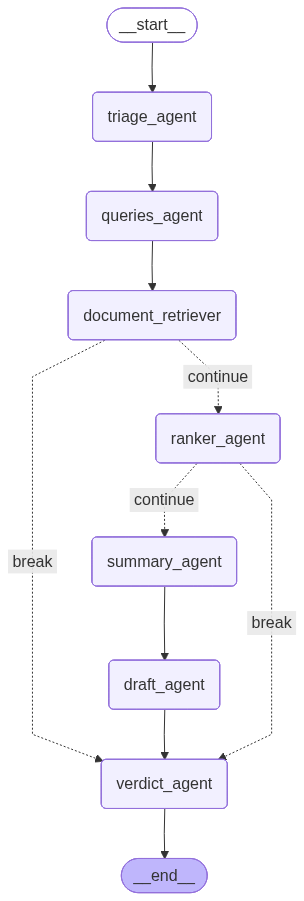

In [27]:
graph = StateGraph(AgentState)

graph.add_node("triage_agent", get_triage)
graph.add_node("queries_agent", get_queries)
graph.add_node("document_retriever", retrieve_documents) 
graph.add_node("ranker_agent", get_ranking)
graph.add_node("summary_agent", get_summary)
graph.add_node("draft_agent", get_draft)
graph.add_node("verdict_agent", get_verdict)

graph.add_edge(START, "triage_agent")
graph.add_edge("triage_agent", "queries_agent")
graph.add_edge("queries_agent", "document_retriever")
graph.add_conditional_edges(
    "document_retriever",
    post_rag,
    {
        "continue": "ranker_agent", # Se tem doc, vai avaliar e sintetizar
        "break": "verdict_agent"    # Se está vazio, pula direto para gerar a frase de erro
    }
)
graph.add_conditional_edges(
    "ranker_agent",
    post_rag,
    {
        "continue": "summary_agent",
        "break": "verdict_agent"
    }
)
graph.add_edge("summary_agent", "draft_agent")
graph.add_edge("draft_agent", "verdict_agent")
graph.add_edge("verdict_agent", END)

compiled_graph = graph.compile()

display(Image(compiled_graph.get_graph(xray=True).draw_mermaid_png()))

### Executando o fluxo

In [28]:
from IPython.utils.capture import capture_output

async def processar_lote(caminho_arquivo_entrada: str, caminho_arquivo_saida: str = "resultados2.json"):
   
    with open(caminho_arquivo_entrada, 'r', encoding='utf-8') as f:
        dados_entrada = json.load(f)
    
    if os.path.exists(caminho_arquivo_saida):
        with open(caminho_arquivo_saida, 'r', encoding='utf-8') as f:
            historico_resultados = json.load(f)
    else:
        historico_resultados = []
        
    ids_processados = {item.get("id") for item in historico_resultados}
    
    print(f"📂 Arquivo carregado. Iniciando o processamento de {len(dados_entrada)} entradas...\n")
    
    for item in dados_entrada:
        with capture_output() as captured:
            caso_id = item.get("id")
            mensagem_usuario = item.get("texto")
            
            if caso_id in ids_processados:
                print(f"⏭️ [ID {caso_id}] Já processado anteriormente. Pulando...")
                continue
            
            print(f"🚀 [ID {caso_id}] Processando: \"{mensagem_usuario[:50]}...\"")
            
            estado_inicial = {
                "messages": [HumanMessage(content=mensagem_usuario)],
                "queries": [],
                "rag_docs": {},
                "web_results": [],
                "draft_response": "",
                "verdict": "",
                "demand_obj": {},
                "summary": "",
                "is_verified": False,
                "references": [],
                "link_map": {}
            }
            
            try:
                # Executa o grafo assincronamente por conta do nó de recuperação paralela
                estado_final = await compiled_graph.ainvoke(estado_inicial)
                
                mensagens_limpas = []
                for msg in estado_final.get("messages", []):
                    if hasattr(msg, "content"):
                        mensagens_limpas.append(msg.content)
                    else:
                        mensagens_limpas.append(str(msg))
                # 3. Estrutura o resultado para salvar no dataset de saída
                resultado_caso = {
                    "id": caso_id,
                    "input_usuario": mensagem_usuario,
                    "demanda_estruturada": estado_final.get("demand_obj", ""),
                    "queries_geradas": estado_final.get("queries", []),
                    "documentos_retornados_rag": estado_final.get("rag_docs", []),
                    "sintese_agente_5": estado_final.get("summary", ""),
                    "resposta_gerada": estado_final.get("draft_response", ""),
                    "veredito_validador": estado_final.get("verdict", ""),
                    "fonte_verificada": estado_final.get("is_verified", False),
                    "referencias": estado_final.get("references", []),
                    "historico_mensagens": mensagens_limpas
                }
                historico_resultados.append(resultado_caso)
                
                print(f"✅ [ID {caso_id}] Concluído com sucesso. Veredito: {estado_final.get('verdict', '')}\n")
                
            except Exception as e:
                print(f"❌ [ID {caso_id}] Falha crítica no pipeline: {str(e)}\n")
                historico_resultados.append({
                    "id": caso_id,
                    "input_usuario": mensagem_usuario,
                    "erro": str(e)
                })
                
            with open(caminho_arquivo_saida, 'w', encoding='utf-8') as f:
                json.dump(historico_resultados, f, ensure_ascii=False, indent=4)
        with open("output2.txt", "a") as f:
            f.write(captured.stdout)
        
    print(f"🎉 Processamento concluído! O histórico estruturado foi salvo em: '{caminho_arquivo_saida}'")
    
await processar_lote("casos_teste.json", "resultados_finais.json")
    

📂 Arquivo carregado. Iniciando o processamento de 50 entradas...

🎉 Processamento concluído! O histórico estruturado foi salvo em: 'resultados_finais.json'


In [6]:
from google import genai
import os

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

config = {
    "system_instruction": "" 
    # Para o Gemini puro do seu teste, você pode deixar esse campo vazio ou 
    # apenas colocar uma instrução neutra para garantir que ele não se perca.
}
caminho_arquivo_entrada = "casos_teste.json"
with open(caminho_arquivo_entrada, 'r', encoding='utf-8') as f:
    dados_entrada = json.load(f)
    
caminho_arquivo_saida = "resultados_baseline.json"
if os.path.exists(caminho_arquivo_saida):
    with open(caminho_arquivo_saida, 'r', encoding='utf-8') as f:
        historico_resultados = json.load(f)
else:
    historico_resultados = []
    
ids_processados = {item.get("id") for item in historico_resultados}

for item in dados_entrada:
    caso_id = item.get("id")
    mensagem_usuario = item.get("texto")
    if caso_id in ids_processados:
        print(f"⏭️ [ID {caso_id}] Já processado anteriormente. Pulando...")
        continue
    print(f"🚀 [ID {caso_id}] Processando: \"{mensagem_usuario[:50]}...\"")
    response = client.models.generate_content(
        model="gemini-3.1-flash-lite", 
        contents=mensagem_usuario,
        config=config
    )
    historico_resultados.append({
        "id": caso_id,
        "input_usuario": mensagem_usuario,
        "resposta": response.text
    })
    with open(caminho_arquivo_saida, 'w', encoding='utf-8') as f:
        json.dump(historico_resultados, f, ensure_ascii=False, indent=4)
    print("✅ Resposta: ", response.text[:100], "...\n")
    time.sleep(15)
print(f"🎉 Processamento concluído! O histórico estruturado foi salvo em: '{caminho_arquivo_saida}'")

⏭️ [ID 1] Já processado anteriormente. Pulando...
⏭️ [ID 2] Já processado anteriormente. Pulando...
⏭️ [ID 3] Já processado anteriormente. Pulando...
⏭️ [ID 4] Já processado anteriormente. Pulando...
⏭️ [ID 5] Já processado anteriormente. Pulando...
⏭️ [ID 6] Já processado anteriormente. Pulando...
⏭️ [ID 7] Já processado anteriormente. Pulando...
⏭️ [ID 8] Já processado anteriormente. Pulando...
⏭️ [ID 9] Já processado anteriormente. Pulando...
⏭️ [ID 10] Já processado anteriormente. Pulando...
⏭️ [ID 11] Já processado anteriormente. Pulando...
🚀 [ID 12] Processando: "Meu Deus, olha isso! Vocês viram que foram encontr..."
✅ Resposta:  Essa história que você trouxe circula na internet há anos, mas é importante esclarecermos: **trata-s ...

🚀 [ID 13] Processando: "Olá pessoal, o alerta de hoje vai para o Rio de Ja..."
✅ Resposta:  É importante tratar informações sobre saúde pública com muita cautela e basear-se em dados oficiais  ...

🚀 [ID 14] Processando: "Um jovem foi internado no Ho